In [1]:
# Import necessary dependencies
import warnings
from pathlib import Path

import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay

from dotenv import load_dotenv
load_dotenv()

from extract_features import bert_encode_sentences, openai_encode_sentences

RANDOM_SEED     = 1567640
DATA_PATH = "./data.csv"

warnings.filterwarnings("ignore")

In [2]:
# Load data and preprocess, show the first 10 rows
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"{DATA_PATH} not found.")
df = pd.read_csv(DATA_PATH).dropna(axis=0, how='any')
df["Text"] = (df["Title"].fillna("") + " " + df["Review Text"].fillna("")).str.strip()
df.drop(columns=["Title", "Review Text", "Rating"], inplace=True)
display(df.head(10))

,Unnamed: 0,Clothing ID,Age,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Text
2,2,1077,60,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...
3,3,1049,50,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumps..."
4,4,847,47,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering...
5,5,1080,49,0,4,General,Dresses,Dresses,Not for the very petite I love tracy reese dre...
6,6,858,39,1,1,General Petite,Tops,Knits,Cagrcoal shimmer fun I aded this in my basket ...
7,7,858,39,1,4,General Petite,Tops,Knits,"Shimmer, surprisingly goes with lots I ordered..."
8,8,1077,24,1,0,General,Dresses,Dresses,Flattering I love this dress. i usually get an...
9,9,1077,34,1,0,General,Dresses,Dresses,"Such a fun dress! I'm 5""5' and 125 lbs. i orde..."
10,10,1077,53,0,14,General,Dresses,Dresses,Dress looks like it's made of cheap material D...
12,12,1095,53,1,2,General Petite,Dresses,Dresses,Perfect!!! More and more i find myself reliant...


In [3]:
# Display the final result
final = pd.read_csv("./final.csv")

final_agg = final.groupby(["feature", "model"]).agg(
    accuracy_mean   = ("accuracy",  "mean"),
    accuracy_std    = ("accuracy",  "std"),
    precision_mean  = ("precision", "mean"),
    precision_std   = ("precision", "std"),
    recall_mean     = ("recall",    "mean"),
    recall_std      = ("recall",    "std"),
    f1_mean         = ("f1",        "mean"),
    f1_std          = ("f1",        "std"),
    auc_mean        = ("auc",       "mean"),
    auc_std         = ("auc",       "std"),
).round(4)
display(final_agg)

accuracy_mean  accuracy_std  precision_mean  \
feature model                                                        
bert    KNN                   0.8576        0.0036          0.8442   
        Random                0.5068        0.0067          0.7028   
        Random Forest         0.8455        0.0056          0.8606   
        SGDClassifier         0.8663        0.0084          0.9000   
        Zero R                0.8182        0.0000          0.6694   
openai  KNN                   0.9013        0.0041          0.8965   
        Random                0.5068        0.0067          0.7028   
        Random Forest         0.9160        0.0026          0.9215   
        SGDClassifier         0.9190        0.0044          0.9339   
        Zero R                0.8182        0.0000          0.6694   
tfidf   KNN                   0.8111        0.0047          0.7794   
        Random                0.5068        0.0067          0.7028   
        Random Forest         0.8566        0.0034          0.8499   
        SGDClassifier         0.8381        0.0084          0.8765   
        Zero R                0.8182        0.0000          0.6694   

                       precision_std  recall_mean  recall_std  f1_mean  \
feature model                                                            
bert    KNN                   0.0055       0.8576      0.0036   0.8422   
        Random                0.0066       0.5068      0.0067   0.5627   
        Random Forest         0.0033       0.8455      0.0056   0.8514   
        SGDClassifier         0.0029       0.8663      0.0084   0.8755   
        Zero R                0.0000       0.8182      0.0000   0.7364   
openai  KNN                   0.0045       0.9013      0.0041   0.8966   
        Random                0.0066       0.5068      0.0067   0.5627   
        Random Forest         0.0036       0.9160      0.0026   0.9179   
        SGDClassifier         0.0034       0.9190      0.0044   0.9229   
        Zero R                0.0000       0.8182      0.0000   0.7364   
tfidf   KNN                   0.0053       0.8111      0.0047   0.7875   
        Random                0.0066       0.5068      0.0067   0.5627   
        Random Forest         0.0054       0.8566      0.0034   0.8523   
        SGDClassifier         0.0044       0.8381      0.0084   0.8496   
        Zero R                0.0000       0.8182      0.0000   0.7364   

                       f1_std  auc_mean  auc_std  
feature model                                     
bert    KNN            0.0027    0.8535   0.0172  
        Random         0.0059    0.5000   0.0000  
        Random Forest  0.0047    0.8904   0.0063  
        SGDClassifier  0.0069    0.9373   0.0024  
        Zero R         0.0000    0.5000   0.0000  
openai  KNN            0.0048    0.9308   0.0097  
        Random         0.0059    0.5000   0.0000  
        Random Forest  0.0025    0.9648   0.0018  
        SGDClassifier  0.0038    0.9745   0.0035  
        Zero R         0.0000    0.5000   0.0000  
tfidf   KNN            0.0050    0.6821   0.0098  
        Random         0.0059    0.5000   0.0000  
        Random Forest  0.0045    0.8831   0.0020  
        SGDClassifier  0.0065    0.9051   0.0040  
        Zero R         0.0000    0.5000   0.0000

In [4]:
# Analyze PCA effect of embeddings
bert_embedding = bert_encode_sentences(df["Text"])
llm_embedding = openai_encode_sentences(df["Text"])

pca_bert = PCA().fit(bert_embedding)
pca_llm  = PCA().fit(llm_embedding)

cum_bert = np.cumsum(pca_bert.explained_variance_ratio_)
cum_llm  = np.cumsum(pca_llm.explained_variance_ratio_)

dims = [50, 200, 400]
table = pd.DataFrame({
    "Dimensions": dims,
    "Bert Explained Ratio": [cum_bert[d - 1] for d in dims],
    "LLM Explained Ratio":  [cum_llm[d - 1]  for d in dims],
}).round(4)
display(table)

,Dimensions,Bert Explained Ratio,LLM Explained Ratio
0,50,0.7428,0.4941
1,200,0.9088,0.7379
2,400,0.9683,0.8467


In [5]:
# Calculate the total number of reviews, positive rate, and positive count
total_reviews = df.shape[0]
positive_rate = (df["Recommended IND"] == 1).mean()
positive_count = int(total_reviews * positive_rate)

table = pd.DataFrame(
    {
        "Total Reviews": [total_reviews],
        "Positive Rate": [positive_rate],
        "Positive Count": [positive_count]
    }
).round(4)
display(table)

,Total Reviews,Positive Rate,Positive Count
0,19662,0.8182,16087


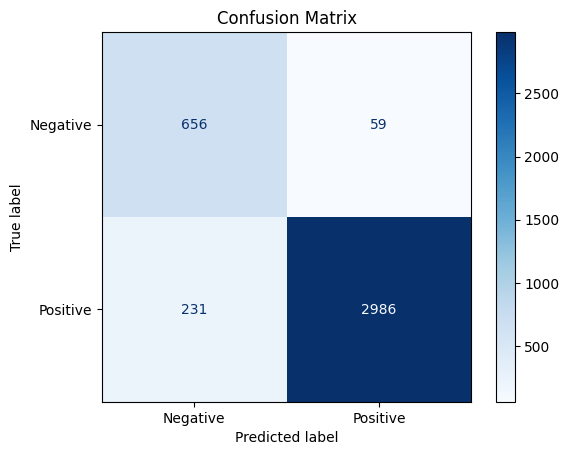

In [6]:
# Find the row with the highest accuracy
cm = final[final["accuracy"] == final["accuracy"].max()]["confusion_matrix"]
cm = re.sub(r'(\d)\s+(\d)', r'\1, \2', cm.values[0]).replace('\n', ',')
cm = np.array(ast.literal_eval(cm))

labels = ["Negative", "Positive"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()